In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("deepu1109/star-dataset")

print("Path to dataset files:", path)

100%|██████████| 3.16k/3.16k [00:00<00:00, 3.62MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/deepu1109/star-dataset/versions/1


In [6]:
df = pd.read_csv("/content/star.csv")

In [7]:
df

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Red,M
1,3042,0.000500,0.1542,16.60,0,Red,M
2,2600,0.000300,0.1020,18.70,0,Red,M
3,2800,0.000200,0.1600,16.65,0,Red,M
4,1939,0.000138,0.1030,20.06,0,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,5,Blue,O
236,30839,834042.000000,1194.0000,-10.63,5,Blue,O
237,8829,537493.000000,1423.0000,-10.73,5,White,A
238,9235,404940.000000,1112.0000,-11.23,5,White,A


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (K)         240 non-null    int64  
 1   Luminosity(L/Lo)        240 non-null    float64
 2   Radius(R/Ro)            240 non-null    float64
 3   Absolute magnitude(Mv)  240 non-null    float64
 4   Star type               240 non-null    int64  
 5   Star color              240 non-null    object 
 6   Spectral Class          240 non-null    object 
dtypes: float64(3), int64(2), object(2)
memory usage: 13.3+ KB


In [9]:
df.isna().sum()

,0
Temperature (K),0
Luminosity(L/Lo),0
Radius(R/Ro),0
Absolute magnitude(Mv),0
Star type,0
Star color,0
Spectral Class,0


In [10]:
df.describe()

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type
count,240.000000,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396,2.500000
std,9552.425037,179432.244940,517.155763,10.532512,1.711394
min,1939.000000,0.000080,0.008400,-11.920000,0.000000
25%,3344.250000,0.000865,0.102750,-6.232500,1.000000
50%,5776.000000,0.070500,0.762500,8.313000,2.500000
75%,15055.500000,198050.000000,42.750000,13.697500,4.000000
max,40000.000000,849420.000000,1948.500000,20.060000,5.000000


In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Star color'] = le.fit_transform(df['Star color'])
df['Spectral Class'] = le.fit_transform(df['Spectral Class'])

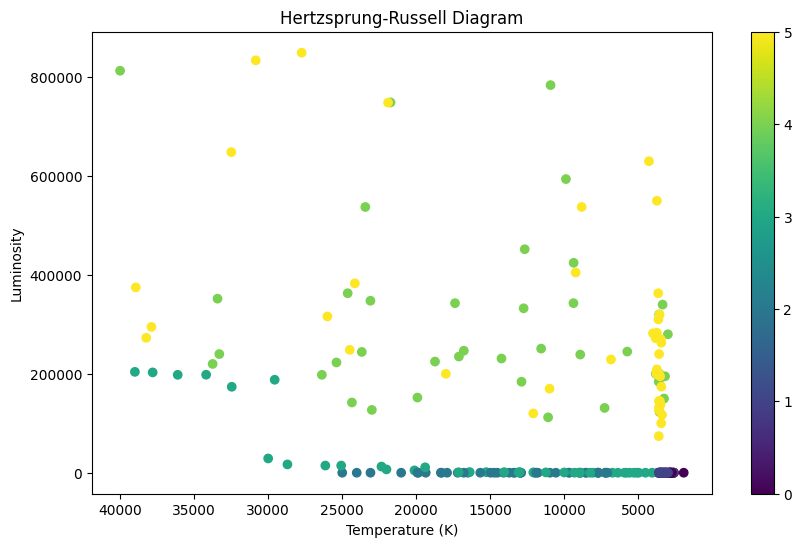

In [12]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    df['Temperature (K)'],
    df['Luminosity(L/Lo)'],
    c=df['Star type'],
    cmap='viridis'
)

plt.gca().invert_xaxis()

plt.xlabel("Temperature (K)")
plt.ylabel("Luminosity")
plt.title("Hertzsprung-Russell Diagram")

plt.colorbar(scatter)

plt.show()

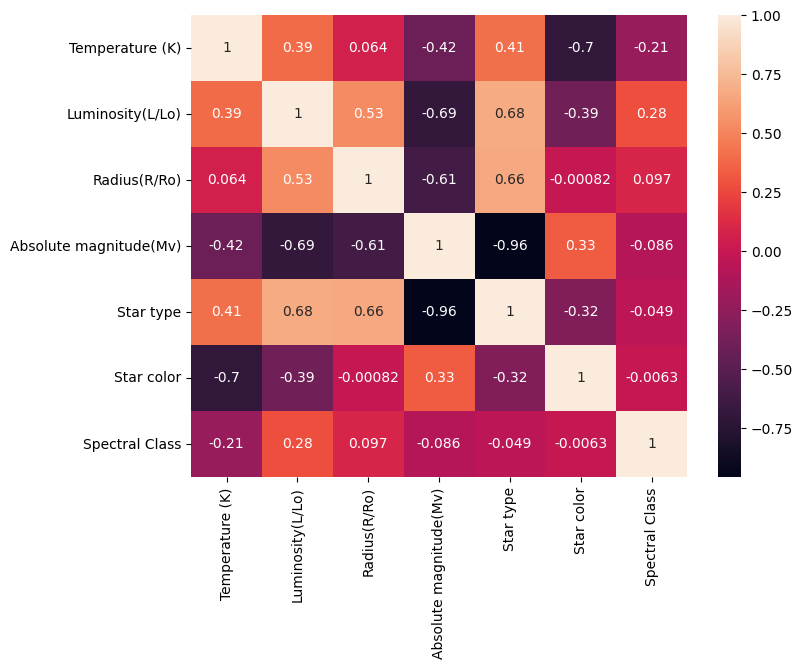

In [13]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.show()

In [14]:
X = df.drop('Star type', axis=1)
y = df['Star type']

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [17]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 1.0


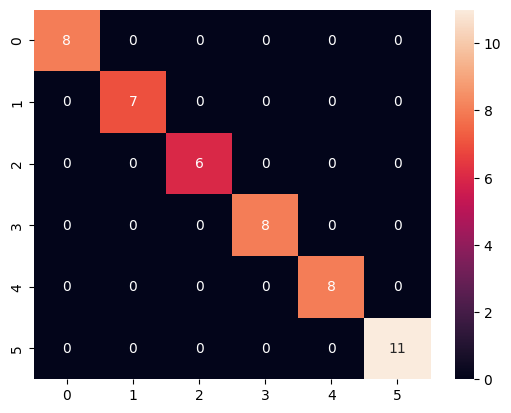

In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True)

plt.show()

In [19]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print(scores)
print(scores.mean())

[1.         0.95833333 1.         1.         1.        ]
0.9916666666666668


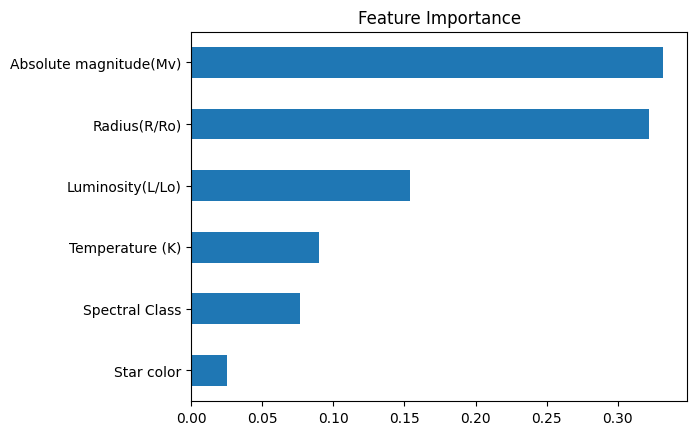

In [20]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()

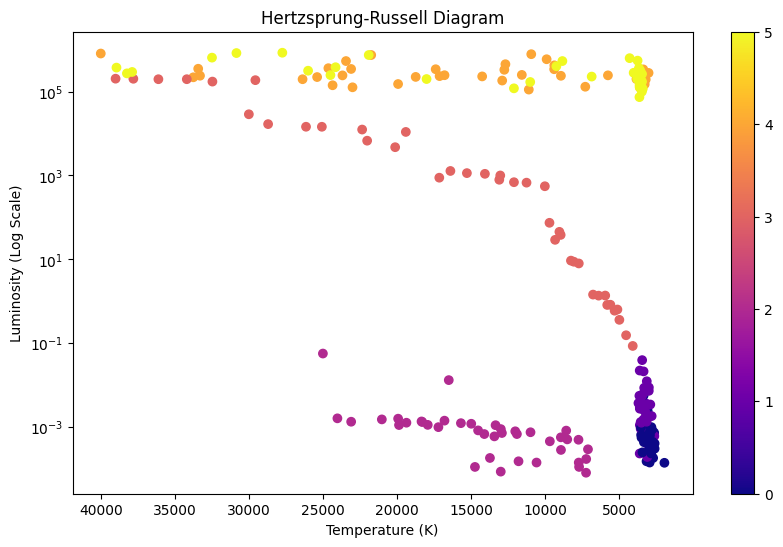

In [21]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    df['Temperature (K)'],
    df['Luminosity(L/Lo)'],
    c=df['Star type'],
    cmap='plasma'
)

plt.yscale('log')

plt.gca().invert_xaxis()

plt.xlabel("Temperature (K)")
plt.ylabel("Luminosity (Log Scale)")
plt.title("Hertzsprung-Russell Diagram")

plt.colorbar(scatter)

plt.show()

In [22]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

In [23]:
import joblib

joblib.dump(model, "star_classifier.pkl")

['star_classifier.pkl']

In [32]:
!pip install gradio

In [35]:
import joblib

model = joblib.load("star_classifier.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [36]:
import gradio as gr
import numpy as np
import joblib

# Load model
model = joblib.load("star_classifier.pkl")

# Prediction function
def predict_star(
    temp,
    luminosity,
    radius,
    magnitude,
    color,
    spectral
):

    features = np.array([[
        temp,
        luminosity,
        radius,
        magnitude,
        color,
        spectral
    ]])

    prediction = model.predict(features)[0]

    star_types = {
        0: "Brown Dwarf",
        1: "Red Dwarf",
        2: "White Dwarf",
        3: "Main Sequence",
        4: "Supergiant",
        5: "Hypergiant"
    }

    return star_types[prediction]

# Create interface
interface = gr.Interface(
    fn=predict_star,

    inputs=[
        gr.Number(label="Temperature (K)"),
        gr.Number(label="Luminosity (L/Lo)"),
        gr.Number(label="Radius (R/Ro)"),
        gr.Number(label="Absolute Magnitude"),
        gr.Number(label="Star Color Encoded"),
        gr.Number(label="Spectral Class Encoded")
    ],

    outputs="text",

    title="🌌 Star Evolution Analyzer",

    description="Predict star types using stellar properties."
)

# Launch app
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bc20d9d8ba0c001308.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
